# Pipeline Tag Prediction
## Baseline - TF-IDF & Logistic Regression

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements the baseline model using TF-IDF and Logistic Regression. It runs in this order:

1. Load cleaned dataset
2. Train/test/validation split
3. Format model card text
4. Setup TF-IDF and encode labels
5. Logistic regression model
6. Predictions and metric analysis
7. Error analysis
8. Export dataframes for improvement models

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Cleaned Dataset

Importing the cleaned dataset from `model_cards_cleaned.parquet`. See data cleaning file for specifics.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'
df = pd.read_parquet(f'{DRIVE_DIR}/model_cards_cleaned.parquet')
metadata = json.load(open(f'{DRIVE_DIR}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [ ]:
# Preview dataset for current columns and data formats
df.head()

,modelId,pipeline_tag,label,text,char_len,word_count
0,00000tt/OmniDream-LoRas,text-to-image,7,# OmniDream FinalDream LoRas\n\n<Gallery />\n\...,305,40
1,00001a/gemma-4-26B-A4B-it-uncensored-heretic-a...,image-text-to-text,2,# 🦆 zecanard/gemma-4-26B-A4B-it-uncensored-her...,1343,139
2,001szp/Qwen3.5-27B-Claude-4.6-Opus-Reasoning-D...,image-text-to-text,2,# 🌟 Qwen3.5-27B-Claude-4.6-Opus-Reasoning-Dist...,7758,919
3,0057Kanyakorn/distilbert-base-uncased-finetune...,text-classification,5,<!-- This model card has been generated automa...,1425,187
4,006aman/IKS-Mistral-7B,text-generation,6,# Uploaded finetuned model\n\n- **Developed b...,442,33


In [ ]:
df.count()

,0
modelId,145003
pipeline_tag,145003
label,145003
text,145003
char_len,145003
word_count,145003


In [ ]:
df.value_counts("pipeline_tag")

,count
pipeline_tag,
text-generation,69696
text-to-image,22021
image-text-to-text,12704
text-classification,10408
translation,8624
automatic-speech-recognition,5986
robotics,4296
token-classification,4113
sentence-similarity,3805


## 2. Split Data

Split the data into train, validation, and test dataframes using an 80/10/10 split.

In [ ]:
# train/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
# val split
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [ ]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (116002, 6)
Shape of validation: (14501, 6)
Shape of test: (14500, 6)


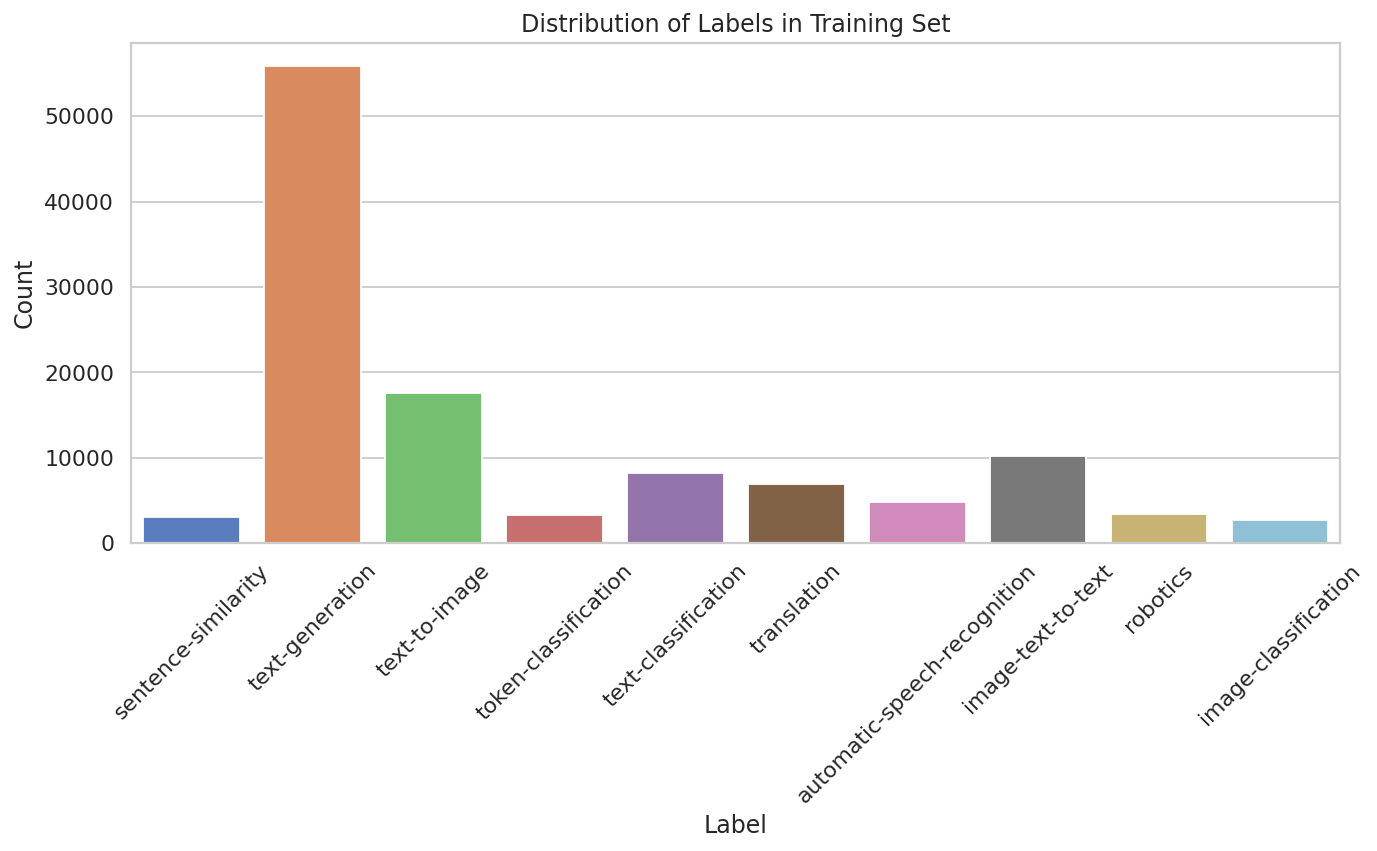

,count
pipeline_tag,
text-generation,55817
text-to-image,17537
image-text-to-text,10165
text-classification,8266
translation,6918
automatic-speech-recognition,4764
robotics,3435
token-classification,3324
sentence-similarity,3096


In [ ]:
# Preview label distribution in the training dataset
sns.countplot(x='pipeline_tag', data=train_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

train_df["pipeline_tag"].value_counts()

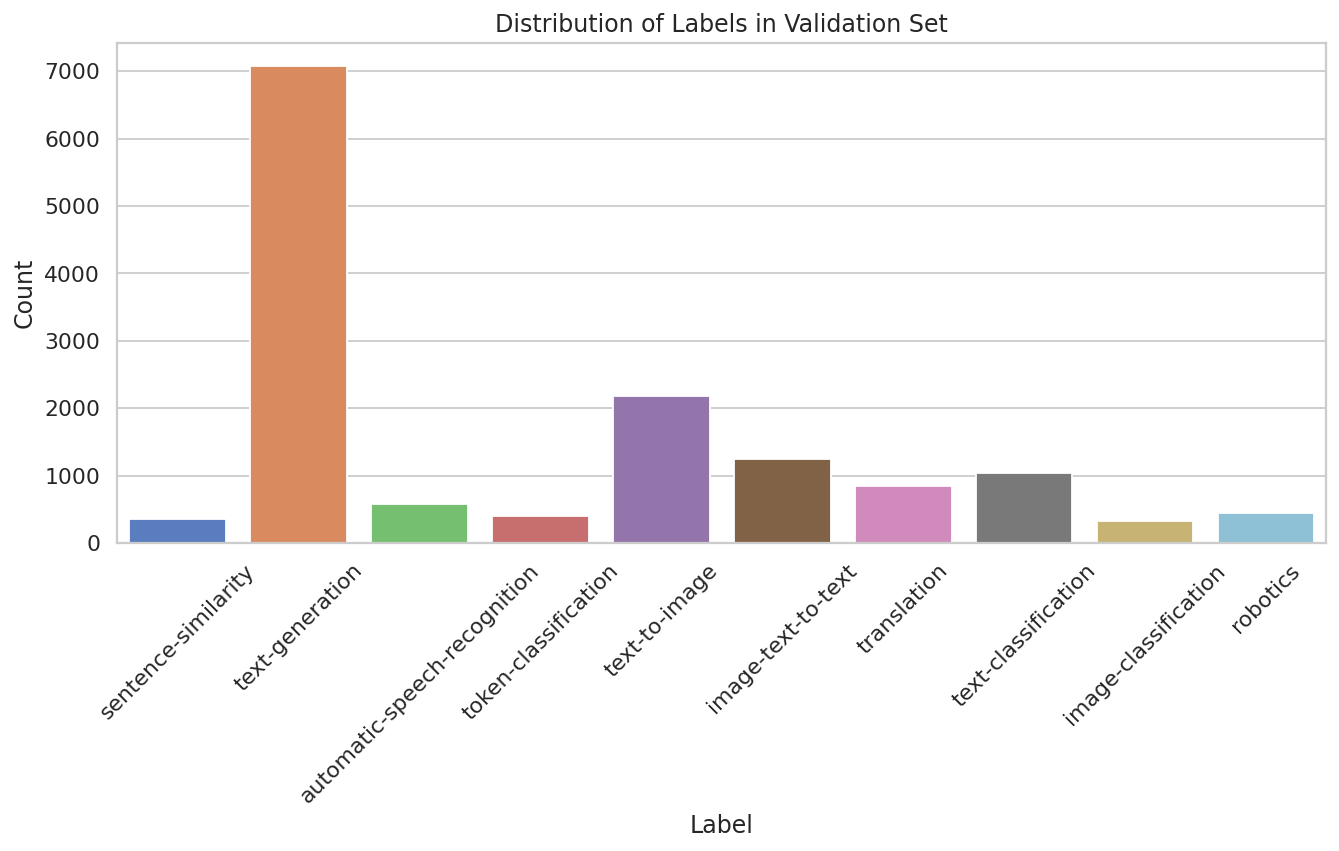

,count
pipeline_tag,
text-generation,7069
text-to-image,2185
image-text-to-text,1251
text-classification,1047
translation,849
automatic-speech-recognition,583
robotics,440
token-classification,395
sentence-similarity,359


In [ ]:
# Preview label distribution in the validation dataset
sns.countplot(x='pipeline_tag', data=val_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Validation Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

val_df["pipeline_tag"].value_counts()

## 3. Format Inputs

Clean the model card text by changing all letters to lowercase, removing punctuation, removing numbers, and collapsing whitespace, prior to fitting the data.

In [ ]:
# Define cleaning function
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# Apply clean_text to train set
train_df['text_clean']  = train_df['text'].apply(clean_text)
# Apply clean_text to test set
test_df['text_clean']  = test_df['text'].apply(clean_text)
# Apply clean_text to validation set
val_df['text_clean']  = val_df['text'].apply(clean_text)

Print a cleaned example:

In [ ]:
# raw unformatted:
print(f'\ntrain: raw answer  : "{train_df["text"].iloc[0]}"')


train: raw answer  : "# fuckoff11/Qodo-Embed-1-1.5B-Q4_K_M-GGUF
This model was converted to GGUF format from [`Qodo/Qodo-Embed-1-1.5B`](https://huggingface.co/Qodo/Qodo-Embed-1-1.5B) using llama.cpp via the ggml.ai's [GGUF-my-repo](https://huggingface.co/spaces/ggml-org/gguf-my-repo) space.
Refer to the [original model card](https://huggingface.co/Qodo/Qodo-Embed-1-1.5B) for more details on the model.

## Use with llama.cpp
Install llama.cpp through brew (works on Mac and Linux)

```bash
brew install llama.cpp

```
Invoke the llama.cpp server or the CLI.

### CLI:
```bash
llama-cli --hf-repo fuckoff11/Qodo-Embed-1-1.5B-Q4_K_M-GGUF --hf-file qodo-embed-1-1.5b-q4_k_m.gguf -p "The meaning to life and the universe is"
```

### Server:
```bash
llama-server --hf-repo fuckoff11/Qodo-Embed-1-1.5B-Q4_K_M-GGUF --hf-file qodo-embed-1-1.5b-q4_k_m.gguf -c 2048
```

Note: You can also use this checkpoint directly through the [usage steps](https://github.com/ggerganov/llama.cpp?tab=readme-ov-file#us

In [ ]:
# cleaned
print(f'train: clean answer : "{train_df["text_clean"].iloc[0]}"')

train: clean answer : "fuckoff qodo embed b q k m gguf this model was converted to gguf format from qodo qodo embed b https huggingface co qodo qodo embed b using llama cpp via the ggml ai s gguf my repo https huggingface co spaces ggml org gguf my repo space refer to the original model card https huggingface co qodo qodo embed b for more details on the model use with llama cpp install llama cpp through brew works on mac and linux bash brew install llama cpp invoke the llama cpp server or the cli cli bash llama cli hf repo fuckoff qodo embed b q k m gguf hf file qodo embed b q k m gguf p the meaning to life and the universe is server bash llama server hf repo fuckoff qodo embed b q k m gguf hf file qodo embed b q k m gguf c note you can also use this checkpoint directly through the usage steps https github com ggerganov llama cpp tab readme ov file usage listed in the llama cpp repo as well step clone llama cpp from github git clone https github com ggerganov llama cpp step move into t

## 4. TF-IDF & Encoding

Setup the TF-IDF vectorizer. We set the max_features to 20,000 as a starting point. Encode the `pipeline_tag` labels. Fit data with training and validation sets.

In [ ]:
# Set TF-IDF
# using default norm; l2 for cosine similarity
tf_idf_vec = TfidfVectorizer(max_features=20000, # top 20k features
                             ngram_range=(1,2), # allows bigrams and unigrams
                             sublinear_tf=True, # allow sublinear scaling to reduce skewing to most frequent words (applies a log to term frequency)
                             min_df=5, # dropping any words that show up <5 times
                             )

In [ ]:
label_encoder = LabelEncoder()

# Fit w/ training and val
X_train = tf_idf_vec.fit_transform(train_df["text_clean"])
X_val = tf_idf_vec.transform(val_df["text_clean"])

# Fit w/ test
X_test = tf_idf_vec.transform(test_df["text_clean"])

# Encode text labels to int categories
Y_train = label_encoder.fit_transform(train_df["pipeline_tag"])
Y_val = label_encoder.transform(val_df["pipeline_tag"])
Y_test = label_encoder.transform(test_df["pipeline_tag"])

# Print shapes for review
print("Shape of formatted X_train:", X_train.shape)
print("Shape of formatted X_val:", X_val.shape)
print("Shape of formatted X_test:", X_test.shape)
print("Shape of formatted Y_train:", Y_train.shape)
print("Shape of formatted Y_val:", Y_val.shape)
print("Shape of formatted Y_test:", Y_test.shape)

Shape of formatted X_train: (116002, 20000)
Shape of formatted X_val: (14501, 20000)
Shape of formatted X_test: (14500, 20000)
Shape of formatted Y_train: (116002,)
Shape of formatted Y_val: (14501,)
Shape of formatted Y_test: (14500,)


## 5. Logistic Regression Baseline (with Data-Scaling Ablation)

Beyond training on the full dataset, we run a data-scaling ablation to understand how the baseline's performance varies with training set size. The model is retrained from scratch on 25%, 50%, 75%, and 100% of the training data and evaluated on the same test set each time. For every run we record accuracy, macro F1, and weighted F1 so we can compare data efficiency against the RoBERTa and ModernBERT improvement models.


In [ ]:
# Baseline w/ Logistic Regression

train_fractions = [0.25, 0.50, 0.75, 1.00]
ablation_results = []

n_train = X_train.shape[0]
shuffled_idx = np.random.RandomState(42).permutation(n_train)

# loop for data scaling ablation
for i in train_fractions:
    print(f"\n=== Training Logistic Regression on {int(i * 100)}% of training data ===")

    n_samples = int(n_train * i)
    idx = shuffled_idx[:n_samples]
    X_train_subset = X_train[idx]
    Y_train_subset = Y_train[idx]

    # Clean model per run
    lr_model = LogisticRegression(max_iter=1000,
                                  class_weight="balanced",
                                  random_state=42,
                                  n_jobs=-1
                                  )

    lr_model.fit(X_train_subset, Y_train_subset)

    test_predictions = lr_model.predict(X_test)

    ablation_results.append({
        "model": "Logistic Regression (TF-IDF)",
        "train_fraction": i,
        "train_samples": n_samples,
        "accuracy": accuracy_score(Y_test, test_predictions),
        "macro_f1": f1_score(Y_test, test_predictions, average="macro"),
        "weighted_f1": f1_score(Y_test, test_predictions, average="weighted"),
    })

    # storing F1 per class per fraction of train set to explore areas for improvement
    per_class_f1 = f1_score(Y_test, test_predictions, average=None, labels=range(len(label_encoder.classes_)))
    ablation_results[-1]["per_class_f1"] = dict(zip(label_encoder.classes_, per_class_f1))


=== Training Logistic Regression on 25% of training data ===

=== Training Logistic Regression on 50% of training data ===

=== Training Logistic Regression on 75% of training data ===

=== Training Logistic Regression on 100% of training data ===


In [ ]:
# Data-scaling ablation results (accuracy, macro F1, weighted F1 per training fraction, per class F1)

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,model,train_fraction,train_samples,accuracy,macro_f1,weighted_f1,per_class_f1
0,Logistic Regression (TF-IDF),0.25,29000,0.932828,0.939816,0.934852,{'automatic-speech-recognition': 0.98130841121...
1,Logistic Regression (TF-IDF),0.50,58001,0.940207,0.946669,0.941851,{'automatic-speech-recognition': 0.98212898212...
2,Logistic Regression (TF-IDF),0.75,87001,0.945793,0.950640,0.947047,{'automatic-speech-recognition': 0.98521400778...
3,Logistic Regression (TF-IDF),1.00,116002,0.946759,0.952256,0.948107,{'automatic-speech-recognition': 0.98753894080...


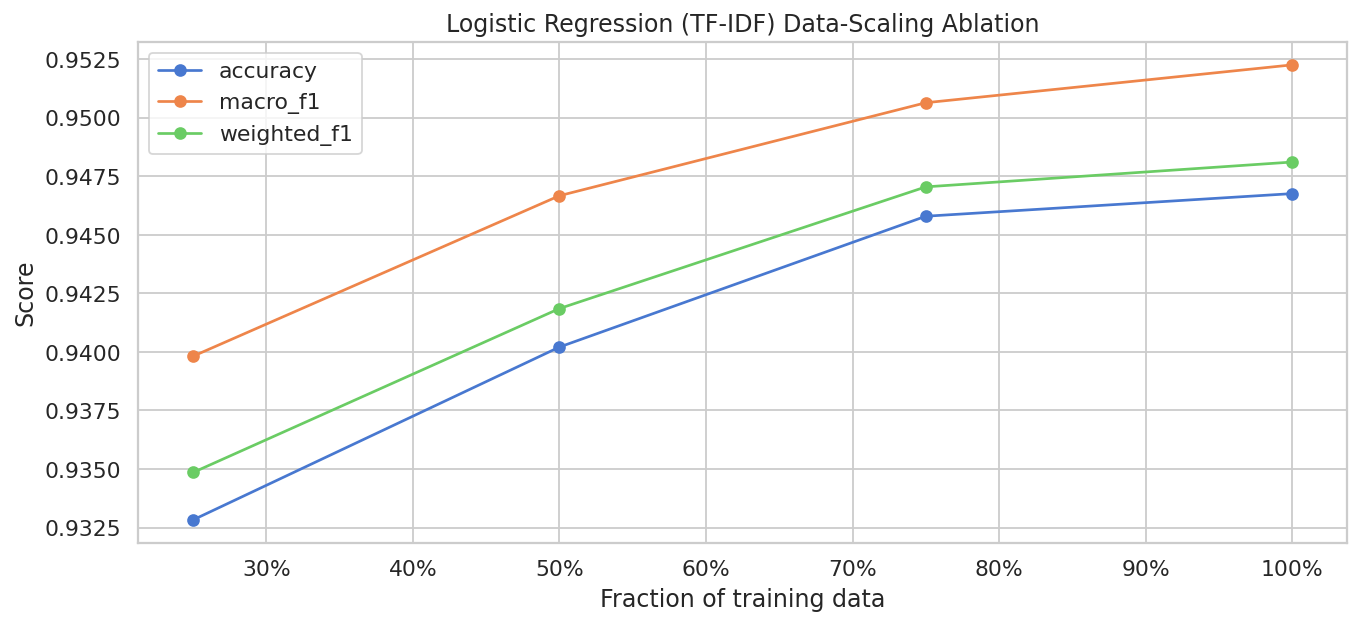

In [ ]:
# Plot learning curves: metric vs. training data fraction

fig, ax = plt.subplots()
for metric_name in ["accuracy", "macro_f1", "weighted_f1"]:
    ax.plot(ablation_df["train_fraction"], ablation_df[metric_name], marker="o", label=metric_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("Score")
ax.set_title("Logistic Regression (TF-IDF) Data-Scaling Ablation")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend()
plt.show()

## 6. Predictions and Metrics

Use the logistic regression model to generate predictions for the validation and finally the test datasets. Generate accuracy and macro-F1 scores to evaluate the model on each dataset.

In [ ]:
# Save predictions
val_predictions = lr_model.predict(X_val)
test_predictions = lr_model.predict(X_test)

In [ ]:
# Print relevant metrics
print("Validation Accuracy:", accuracy_score(Y_val, val_predictions))
print("Validation Macro-F1:", f1_score(Y_val, val_predictions, average="macro"))

print("Test Accuracy:", accuracy_score(Y_test, test_predictions))
print("Test Macro-F1:", f1_score(Y_test, test_predictions, average="macro"))

Validation Accuracy: 0.9452451555065168
Validation Macro-F1: 0.9481360056343302
Test Accuracy: 0.9467586206896552
Test Macro-F1: 0.9522555677256909


In [ ]:
# Print classification report to analyze metrics per `pipeline_tag` label
print(classification_report(Y_test, test_predictions, target_names=label_encoder.classes_))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.98      0.99      0.99       639
        image-classification       0.96      0.98      0.97       347
          image-text-to-text       0.74      0.92      0.82      1288
                    robotics       0.96      0.99      0.97       421
         sentence-similarity       0.97      0.99      0.98       350
         text-classification       0.90      0.95      0.92      1095
             text-generation       0.98      0.92      0.95      6810
               text-to-image       1.00      0.99      1.00      2299
        token-classification       0.95      0.95      0.95       394
                 translation       0.98      0.97      0.98       857

                    accuracy                           0.95     14500
                   macro avg       0.94      0.97      0.95     14500
                weighted avg       0.95      0.95      0.95     14500



## 7. Error Analysis



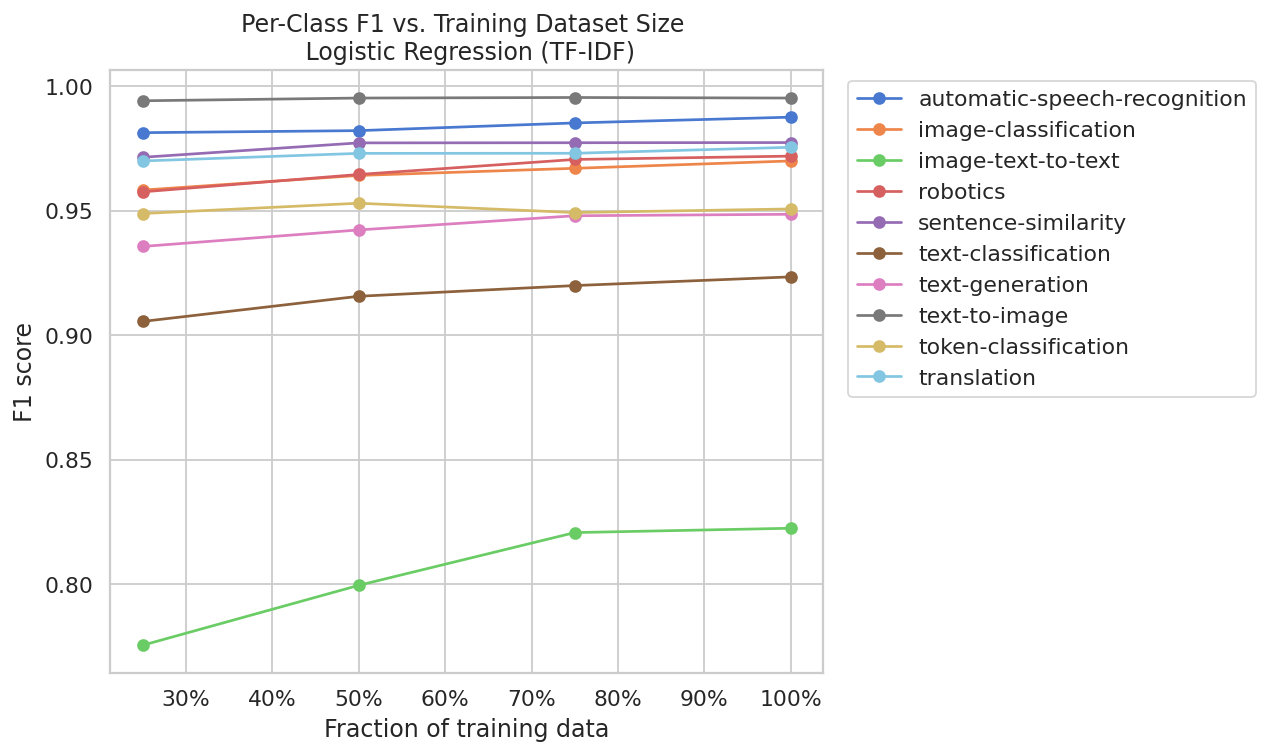

In [ ]:
# Per class F1 - does it improve with more data?

per_class_df = pd.DataFrame([r["per_class_f1"] for r in ablation_results])
per_class_df["train_fraction"] = ablation_df["train_fraction"]

fig, ax = plt.subplots(figsize=(10, 6))
for class_name in label_encoder.classes_:
    ax.plot(per_class_df["train_fraction"], per_class_df[class_name], marker="o", label=class_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("F1 score")
ax.set_title("Per-Class F1 vs. Training Dataset Size \n Logistic Regression (TF-IDF)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

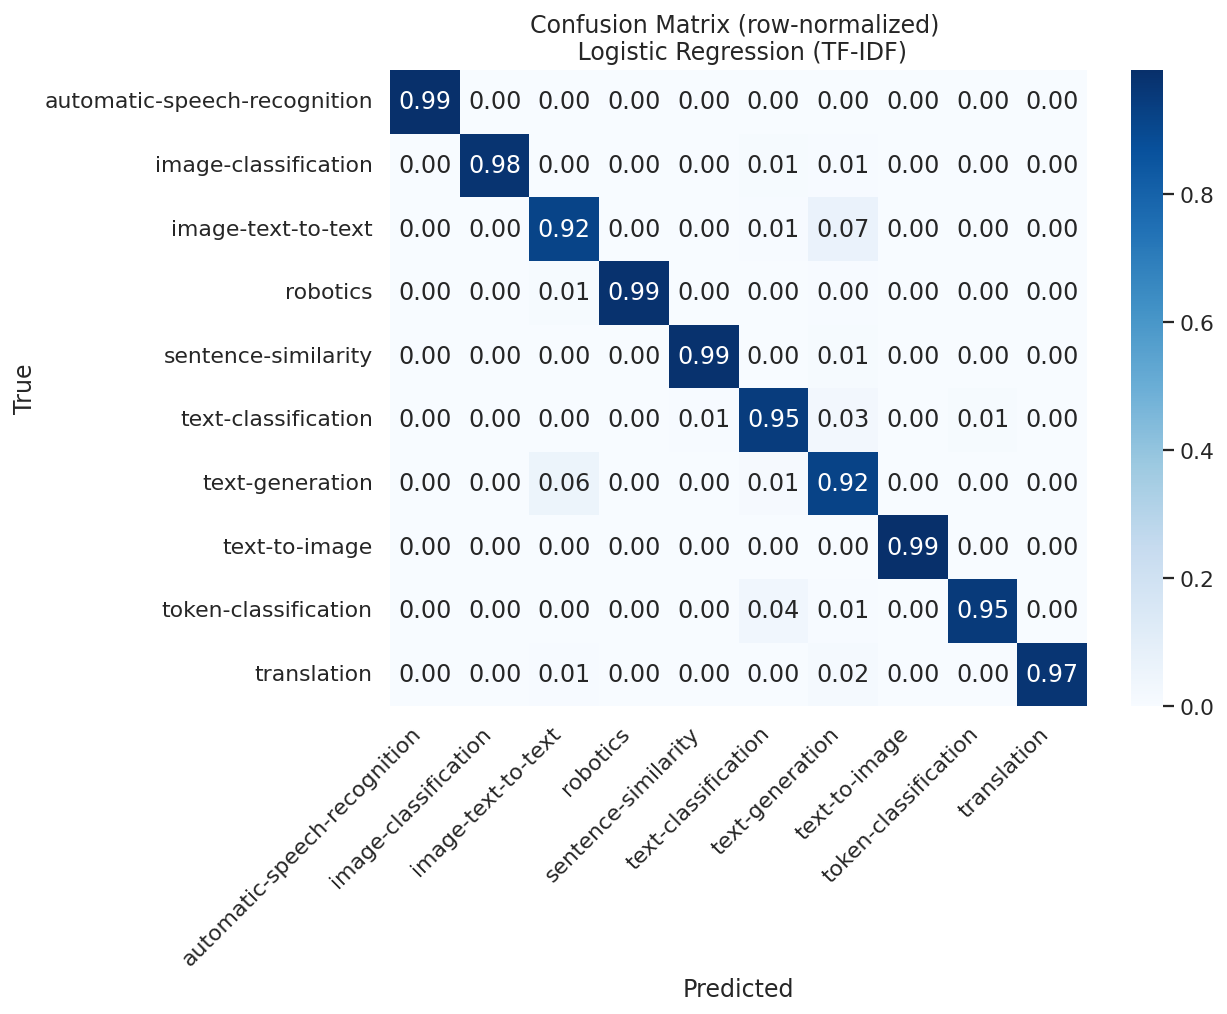

In [ ]:
# Confusion Matrix - recall

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, test_predictions, normalize="true")
labels = label_encoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized) \n Logistic Regression (TF-IDF)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# top 10 mislabeled/confused and counts for each confusion pair
cm_counts = confusion_matrix(Y_test, test_predictions)
np.fill_diagonal(cm_counts, 0)

confusion_pairs = []
for i in range(cm_counts.shape[0]):
    for j in range(cm_counts.shape[1]):
        if cm_counts[i, j] > 0:
            confusion_pairs.append({
                "true_label": labels[i],
                "predicted_label": labels[j],
                "count": cm_counts[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values("count", ascending=False)
confusion_df.head(10)

,true_label,predicted_label,count
27,text-generation,image-text-to-text,390
13,image-text-to-text,text-generation,88
30,text-generation,text-classification,87
22,text-classification,text-generation,33
33,text-generation,translation,18
40,token-classification,text-classification,14
47,translation,text-generation,14
32,text-generation,token-classification,10
24,text-classification,token-classification,10
31,text-generation,text-to-image,8


In [ ]:
# Check actual documents that were misclassified based on confusion matrix

test_df_reset = test_df.reset_index(drop=True)
test_df_reset["true_label"] = label_encoder.inverse_transform(Y_test)
test_df_reset["predicted_label"] = label_encoder.inverse_transform(test_predictions)
test_df_reset["correct"] = test_df_reset["true_label"] == test_df_reset["predicted_label"]

# Worst confusion pair from confusion_df
top_pair = confusion_df.iloc[0]
mask = (test_df_reset["true_label"] == top_pair["true_label"]) & \
       (test_df_reset["predicted_label"] == top_pair["predicted_label"])

misclassified_sample = test_df_reset.loc[mask, ["text", "true_label", "predicted_label"]].sample(
    min(5, mask.sum()), random_state=42
)

for _, row in misclassified_sample.iterrows():
    print(f"TRUE: {row['true_label']} | PRED: {row['predicted_label']}")
    print(row["text"][:500])
    print("-" * 80)

TRUE: text-generation | PRED: image-text-to-text
# BlankHtmlPage/Qwopus3.5-9B-v3.5-Q8_0-GGUF
This model was converted to GGUF format from [`Jackrong/Qwopus3.5-9B-v3.5`](https://huggingface.co/Jackrong/Qwopus3.5-9B-v3.5) using llama.cpp via the ggml.ai's [GGUF-my-repo](https://huggingface.co/spaces/ggml-org/gguf-my-repo) space.
Refer to the [original model card](https://huggingface.co/Jackrong/Qwopus3.5-9B-v3.5) for more details on the model.

## Use with llama.cpp
Install llama.cpp through brew (works on Mac and Linux)

```bash
brew install ll
--------------------------------------------------------------------------------
TRUE: text-generation | PRED: image-text-to-text
# Uploaded finetuned  model

- **Developed by:** nathangalung
- **License:** apache-2.0
- **Finetuned from model :** nathangalung/qwen2.5-1.5b-alpaca-indonesian-sft

This qwen2 model was trained 2x faster with [Unsloth](https://github.com/unslothai/unsloth) and Huggingface's TRL library.

[<img src="https://raw.githubu

In [ ]:
N_PAIRS = 5
EXAMPLES_PER_PAIR = 3

for _, pair in confusion_df.head(N_PAIRS).iterrows():
    true_label = pair["true_label"]
    pred_label = pair["predicted_label"]

    mask = (test_df_reset["true_label"] == true_label) & \
           (test_df_reset["predicted_label"] == pred_label)

    sample = test_df_reset.loc[mask, ["text", "true_label", "predicted_label"]].sample(
        min(EXAMPLES_PER_PAIR, mask.sum()), random_state=42
    )

    print(f"\n{'='*90}")
    print(f"TRUE: {true_label}  ->  PREDICTED: {pred_label}   ({pair['count']} occurrences)")
    print('='*90)
    for _, row in sample.iterrows():
        print(f"\n---\n{row['text'][:600]}")


TRUE: text-generation  ->  PREDICTED: image-text-to-text   (390 occurrences)

---
# BlankHtmlPage/Qwopus3.5-9B-v3.5-Q8_0-GGUF
This model was converted to GGUF format from [`Jackrong/Qwopus3.5-9B-v3.5`](https://huggingface.co/Jackrong/Qwopus3.5-9B-v3.5) using llama.cpp via the ggml.ai's [GGUF-my-repo](https://huggingface.co/spaces/ggml-org/gguf-my-repo) space.
Refer to the [original model card](https://huggingface.co/Jackrong/Qwopus3.5-9B-v3.5) for more details on the model.

## Use with llama.cpp
Install llama.cpp through brew (works on Mac and Linux)

```bash
brew install llama.cpp

```
Invoke the llama.cpp server or the CLI.

### CLI:
```bash
llama-cli --hf-repo BlankHtml

---
# Uploaded finetuned  model

- **Developed by:** nathangalung
- **License:** apache-2.0
- **Finetuned from model :** nathangalung/qwen2.5-1.5b-alpaca-indonesian-sft

This qwen2 model was trained 2x faster with [Unsloth](https://github.com/unslothai/unsloth) and Huggingface's TRL library.

[<img src="https://ra

In [ ]:
# checking vocab overlaps in confused pairs
feature_names = np.array(tf_idf_vec.get_feature_names_out())
TOP_K = 30

for _, pair in confusion_df.head(N_PAIRS).iterrows():
    true_idx = list(label_encoder.classes_).index(pair["true_label"])
    pred_idx = list(label_encoder.classes_).index(pair["predicted_label"])

    true_top = set(feature_names[np.argsort(lr_model.coef_[true_idx])[-TOP_K:]])
    pred_top = set(feature_names[np.argsort(lr_model.coef_[pred_idx])[-TOP_K:]])

    overlap = true_top & pred_top
    print(f"\n{pair['true_label']} vs {pair['predicted_label']}")
    print(f"  Shared top-{TOP_K} features: {len(overlap)}  -> {sorted(overlap)}")


text-generation vs image-text-to-text
  Shared top-30 features: 2  -> ['qwen', 'sft']

image-text-to-text vs text-generation
  Shared top-30 features: 2  -> ['qwen', 'sft']

text-generation vs text-classification
  Shared top-30 features: 0  -> []

text-classification vs text-generation
  Shared top-30 features: 0  -> []

text-generation vs translation
  Shared top-30 features: 0  -> []


In [ ]:
def explain_prediction(row_idx, top_k=10):
    x = X_test[row_idx]
    true_label = test_df_reset.loc[row_idx, "true_label"]
    pred_label = test_df_reset.loc[row_idx, "predicted_label"]
    pred_idx = list(label_encoder.classes_).index(pred_label)

    # contribution = tfidf weight * coefficient for the predicted class
    contributions = x.multiply(lr_model.coef_[pred_idx]).toarray().flatten()
    top_idx = np.argsort(contributions)[-top_k:][::-1]

    print(f"TRUE: {true_label}  PRED: {pred_label}")
    print(f"Text: {test_df_reset.loc[row_idx, 'text'][:300]}")
    print("Top words pushing toward the (wrong) prediction:")
    for i in top_idx:
        if contributions[i] > 0:
            print(f"  {feature_names[i]:<25} contribution={contributions[i]:.4f}")
    print()

# Worst pairs
top_pair = confusion_df.iloc[0]
mask = (test_df_reset["true_label"] == top_pair["true_label"]) & \
       (test_df_reset["predicted_label"] == top_pair["predicted_label"])
sample_idx = test_df_reset.loc[mask].sample(min(3, mask.sum()), random_state=42).index

for idx in sample_idx:
    explain_prediction(idx)

TRUE: text-generation  PRED: image-text-to-text
Text: # BlankHtmlPage/Qwopus3.5-9B-v3.5-Q8_0-GGUF
This model was converted to GGUF format from [`Jackrong/Qwopus3.5-9B-v3.5`](https://huggingface.co/Jackrong/Qwopus3.5-9B-v3.5) using llama.cpp via the ggml.ai's [GGUF-my-repo](https://huggingface.co/spaces/ggml-org/gguf-my-repo) space.
Refer to the [origin
Top words pushing toward the (wrong) prediction:
  qwopus                    contribution=0.5349
  gguf                      contribution=0.1874
  jackrong                  contribution=0.1847
  llama cpp                 contribution=0.1594
  jackrong qwopus           contribution=0.1477
  cpp                       contribution=0.1261
  hf                        contribution=0.1142
  the llama                 contribution=0.0629
  hf file                   contribution=0.0561
  ggml                      contribution=0.0523

TRUE: text-generation  PRED: image-text-to-text
Text: # Uploaded finetuned  model

- **Developed by:** nathangalung

In [ ]:
vision_terms = ["image", "vision", "visual", "multimodal", "vlm", "vqa", "ocr"]
family_terms = ["gemma", "qwen", "llama", "mistral", "phi"]

mask = (test_df_reset["predicted_label"] == "image-text-to-text") & \
       (test_df_reset["true_label"] != "image-text-to-text")

subset = test_df_reset.loc[mask, "text_clean"]  # <-- clean, not raw

has_family = subset.apply(lambda t: any(f in t for f in family_terms))
has_vision = subset.apply(lambda t: any(v in t for v in vision_terms))

print(f"Misclassified as image-text-to-text: {mask.sum()}")
print(f"  mentions a model-family name: {has_family.sum()}")
print(f"  mentions family name but NO vision term: {(has_family & ~has_vision).sum()}")

Misclassified as image-text-to-text: 407
  mentions a model-family name: 379
  mentions family name but NO vision term: 152


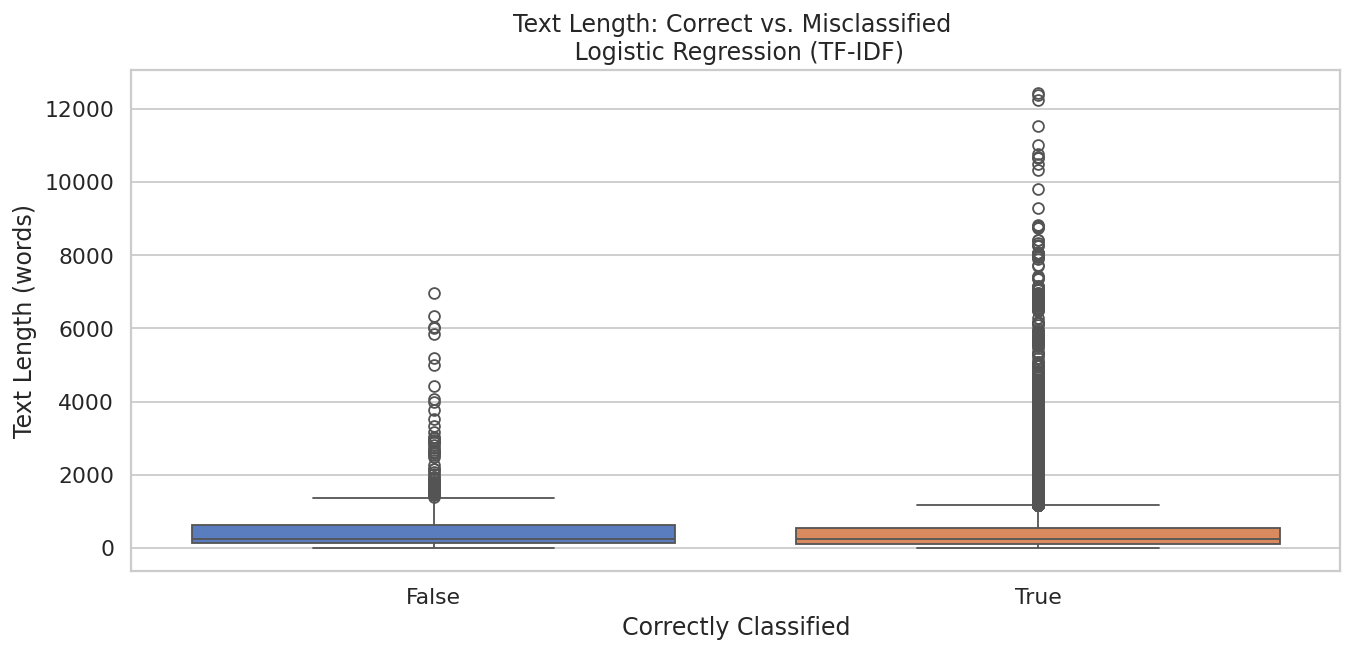

           count        mean         std  min    25%    50%    75%      max
correct                                                                    
False      772.0  534.510363  810.402863  1.0  137.0  240.0  632.0   6977.0
True     13728.0  499.748325  879.082219  3.0  114.0  233.0  536.0  12435.0


In [ ]:
# Text length analysis on mislabeled docs

test_df_reset["text_length"] = test_df_reset["text"].str.split().str.len()

fig, ax = plt.subplots()
sns.boxplot(data=test_df_reset, x="correct", y="text_length", hue="correct", ax=ax, legend=False)
ax.set_xlabel("Correctly Classified")
ax.set_ylabel("Text Length (words)")
ax.set_title("Text Length: Correct vs. Misclassified \n Logistic Regression (TF-IDF)")
plt.show()

print(test_df_reset.groupby("correct")["text_length"].describe())

## 8. Export data

Export the train, test, and validation dataframes to use the exact same data split for the improvement models: RoBERTa and ModernBERT. This ensures consistency in our metric and model evaluations.

In [ ]:
# Set new google drive directory path
DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'
# Save each dataframe to a parquet
train_df.to_parquet(f'{DRIVE_DIR}/train_df.parquet', index=False)
val_df.to_parquet(f'{DRIVE_DIR}/val_df.parquet', index=False)
test_df.to_parquet(f'{DRIVE_DIR}/test_df.parquet', index=False)

To load these dataframes into a new notebook for the improvement model, use this code block:

```python
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']
```

## 00. Extra working space

misc data checks - `delete later`

In [ ]:
max_length = train_df["text"].str.len().max()
max_length

99615

In [ ]:
avg_len = train_df["text"].str.len().mean()
avg_len

np.float64(4371.318442785469)

In [ ]:
train_df["text"].str.len().describe()

,text
count,116002.000000
mean,4371.318443
std,7855.075210
min,100.000000
25%,1070.000000
50%,2052.000000
75%,4543.000000
max,99615.000000
